# Gaussian Rasterization — Visual Experiments

> **Goal:** Make the 3DGS rasterizer feel concrete: how a projected Gaussian becomes an ellipse, how tiles localize the work, why sorting by depth matters, and where the speed-up over naive rendering actually comes from.

## What we will explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Projected footprints** | What does a 2D Gaussian footprint look like, and how do we bound it on screen? |
| 2 | **Tile binning** | How does one Gaussian turn into several tile-local jobs? |
| 3 | **Depth-aware queues** | Why do we sort by `(tile, depth)` instead of just keeping one global list? |
| 4 | **Front-to-back compositing** | What changes when the same Gaussians are blended in the wrong order? |
| 5 | **Efficiency breakdown** | How much work do tile culling and early termination save in a toy rasterizer? |

---
**Linked theory:** [research/09-gaussian-rasterization.md](../research/09-gaussian-rasterization.md)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Rectangle
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.30,
})

print('Setup complete.')

Setup complete.


### What you see

1. **What the output shows:** A short setup message confirming the notebook environment is ready.
2. **Why it matters:** This notebook stays intentionally lightweight. We only need `numpy`, `matplotlib`, and a few geometry helpers to expose the rasterization pipeline.
3. **What to take away:** The goal is not to mimic CUDA instruction by instruction. The goal is to preserve the structure of the official rasterizer so the logic is visible.

---
## A tiny rasterizer toolkit

The helpers below keep the pipeline close to the official implementation, but in pure NumPy:

1. Represent each Gaussian by a 2D mean, covariance, depth, opacity, and RGB color.
2. Compute a bounding radius from the largest covariance eigenvalue.
3. Convert each Gaussian into a list of touched tiles.
4. Sort tile-local Gaussian queues by depth.
5. Blend each tile front-to-back with optional early termination.

That is enough to make the algorithm legible without hiding it behind a large codebase.

In [2]:
WIDTH, HEIGHT = 224, 160
TILE = 32
SIGMA_LEVEL = 3.0
MIN_ALPHA = 1.0 / 255.0


def make_gaussian(gid, mean, cov, depth, opacity, color):
    cov = np.asarray(cov, dtype=float)
    inv_cov = np.linalg.inv(cov)
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    radius = float(np.ceil(SIGMA_LEVEL * np.sqrt(max(eigvals[0], 1e-9))))
    return {
        'id': gid,
        'mean': np.asarray(mean, dtype=float),
        'cov': cov,
        'inv_cov': inv_cov,
        'depth': float(depth),
        'opacity': float(opacity),
        'color': np.asarray(color, dtype=float),
        'radius': radius,
        'angle': angle,
        'axes': 2.0 * SIGMA_LEVEL * np.sqrt(np.maximum(eigvals, 1e-9)),
    }


def tile_bounds(gaussian, width=WIDTH, height=HEIGHT, tile=TILE):
    x, y = gaussian['mean']
    r = gaussian['radius']
    min_x = max(0, int(np.floor((x - r) / tile)))
    max_x = min(int(np.ceil(width / tile)), int(np.ceil((x + r) / tile)))
    min_y = max(0, int(np.floor((y - r) / tile)))
    max_y = min(int(np.ceil(height / tile)), int(np.ceil((y + r) / tile)))
    return min_x, max_x, min_y, max_y


def duplicate_by_tile(gaussians, width=WIDTH, height=HEIGHT, tile=TILE):
    duplicates = []
    tile_map = {}
    horizontal_tiles = int(np.ceil(width / tile))
    for gaussian in gaussians:
        min_x, max_x, min_y, max_y = tile_bounds(gaussian, width=width, height=height, tile=tile)
        for ty in range(min_y, max_y):
            for tx in range(min_x, max_x):
                tile_id = ty * horizontal_tiles + tx
                record = {
                    'tile_id': tile_id,
                    'tile_xy': (tx, ty),
                    'depth': gaussian['depth'],
                    'gaussian_id': gaussian['id'],
                }
                duplicates.append(record)
                tile_map.setdefault((tx, ty), []).append(gaussian['id'])
    return duplicates, tile_map


def gaussian_alpha_map(gaussian, xs, ys):
    dx = xs - gaussian['mean'][0]
    dy = ys - gaussian['mean'][1]
    a, b = gaussian['inv_cov'][0, 0], gaussian['inv_cov'][0, 1]
    c = gaussian['inv_cov'][1, 1]
    power = -0.5 * (a * dx * dx + 2.0 * b * dx * dy + c * dy * dy)
    alpha = gaussian['opacity'] * np.exp(power)
    alpha = np.where(alpha >= MIN_ALPHA, np.minimum(alpha, 0.99), 0.0)
    return alpha


def render_scene(gaussians, width=WIDTH, height=HEIGHT, tile=TILE, sort_by_depth=True, early_stop_threshold=1e-4):
    duplicates, tile_map = duplicate_by_tile(gaussians, width=width, height=height, tile=tile)
    horizontal_tiles = int(np.ceil(width / tile))
    vertical_tiles = int(np.ceil(height / tile))
    queues = {key: list(value) for key, value in tile_map.items()}
    if sort_by_depth:
        for tile_key, ids in queues.items():
            queues[tile_key] = sorted(ids, key=lambda gid: gaussians_by_id[gid]['depth'])

    image = np.zeros((height, width, 3), dtype=float)
    final_T = np.ones((height, width), dtype=float)
    tested = np.zeros((height, width), dtype=int)
    contributing = np.zeros((height, width), dtype=int)

    for ty in range(vertical_tiles):
        for tx in range(horizontal_tiles):
            queue = queues.get((tx, ty), [])
            if not queue:
                continue
            x0, x1 = tx * tile, min((tx + 1) * tile, width)
            y0, y1 = ty * tile, min((ty + 1) * tile, height)
            xs, ys = np.meshgrid(np.arange(x0, x1), np.arange(y0, y1))
            tile_rgb = np.zeros((y1 - y0, x1 - x0, 3), dtype=float)
            tile_T = np.ones((y1 - y0, x1 - x0), dtype=float)
            tile_tested = np.zeros_like(tile_T, dtype=int)
            tile_contrib = np.zeros_like(tile_T, dtype=int)

            for gid in queue:
                tile_tested += 1
                gaussian = gaussians_by_id[gid]
                alpha = gaussian_alpha_map(gaussian, xs, ys)
                active = alpha > 0
                tile_rgb += tile_T[..., None] * alpha[..., None] * gaussian['color'][None, None, :]
                tile_contrib += active.astype(int)
                tile_T = tile_T * (1.0 - alpha)
                if early_stop_threshold is not None:
                    done_mask = tile_T < early_stop_threshold
                    if np.all(done_mask):
                        break

            image[y0:y1, x0:x1] = tile_rgb + tile_T[..., None]
            final_T[y0:y1, x0:x1] = tile_T
            tested[y0:y1, x0:x1] = tile_tested
            contributing[y0:y1, x0:x1] = tile_contrib

    return {
        'image': np.clip(image, 0.0, 1.0),
        'final_T': final_T,
        'tested': tested,
        'contributing': contributing,
        'duplicates': duplicates,
        'tile_map': tile_map,
        'queues': queues,
    }


def draw_screen(ax, width=WIDTH, height=HEIGHT, tile=TILE):
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect('equal')
    ax.set_xlabel('x (pixels)')
    ax.set_ylabel('y (pixels)')
    for x in range(0, width + 1, tile):
        ax.axvline(x, color='lightgray', linewidth=0.8, alpha=0.8)
    for y in range(0, height + 1, tile):
        ax.axhline(y, color='lightgray', linewidth=0.8, alpha=0.8)


def add_gaussian_outline(ax, gaussian, label=True, face_alpha=0.18):
    width, height = gaussian['axes']
    ellipse = Ellipse(
        xy=gaussian['mean'],
        width=width,
        height=height,
        angle=gaussian['angle'],
        facecolor=gaussian['color'],
        edgecolor=gaussian['color'],
        linewidth=2.0,
        alpha=face_alpha,
    )
    ax.add_patch(ellipse)
    bound = Rectangle(
        (gaussian['mean'][0] - gaussian['radius'], gaussian['mean'][1] - gaussian['radius']),
        2 * gaussian['radius'],
        2 * gaussian['radius'],
        fill=False,
        linestyle='--',
        linewidth=1.4,
        edgecolor=gaussian['color'],
        alpha=0.9,
    )
    ax.add_patch(bound)
    ax.scatter([gaussian['mean'][0]], [gaussian['mean'][1]], color=gaussian['color'], s=36)
    if label:
        ax.text(
            gaussian['mean'][0] + 3,
            gaussian['mean'][1] - 5,
            f"G{gaussian['id']}\nz={gaussian['depth']:.2f}",
            fontsize=9,
            color='black',
            bbox=dict(boxstyle='round,pad=0.18', facecolor='white', edgecolor=gaussian['color'], alpha=0.85),
        )


base_gaussians = [
    make_gaussian(0, mean=(54, 48),  cov=[[120, 38], [38, 42]], depth=1.2, opacity=0.76, color=(0.91, 0.31, 0.28)),
    make_gaussian(1, mean=(118, 82), cov=[[52, -18], [-18, 96]], depth=2.1, opacity=0.72, color=(0.26, 0.58, 0.91)),
    make_gaussian(2, mean=(170, 58), cov=[[84, 0], [0, 36]], depth=1.7, opacity=0.78, color=(0.30, 0.74, 0.40)),
    make_gaussian(3, mean=(142, 118), cov=[[64, 24], [24, 64]], depth=2.8, opacity=0.82, color=(0.93, 0.73, 0.20)),
]

gaussians_by_id = {g['id']: g for g in base_gaussians}

print('Rasterizer helpers ready.')

Rasterizer helpers ready.


### What you see

1. **What the output shows:** A helper setup message confirming that the toy rasterizer functions and a base scene are loaded.
2. **Why it matters:** The notebook now has the same conceptual stages as the official implementation: projection footprint, tile duplication, queue sorting, and front-to-back blending.
3. **What to take away:** From here on, each figure comes from the same reusable mini-pipeline, so every experiment reflects a structural property of Gaussian rasterization rather than a one-off plotting trick.

---
## Experiment 1: A projected Gaussian is an ellipse with a finite screen-space bound

**Question:** What does the rasterizer actually receive after projection?

In the official code, preprocessing converts each Gaussian into a 2D mean, a conic form, an opacity, and a radius used to build a bounding rectangle in tile space. This experiment visualizes that state directly.

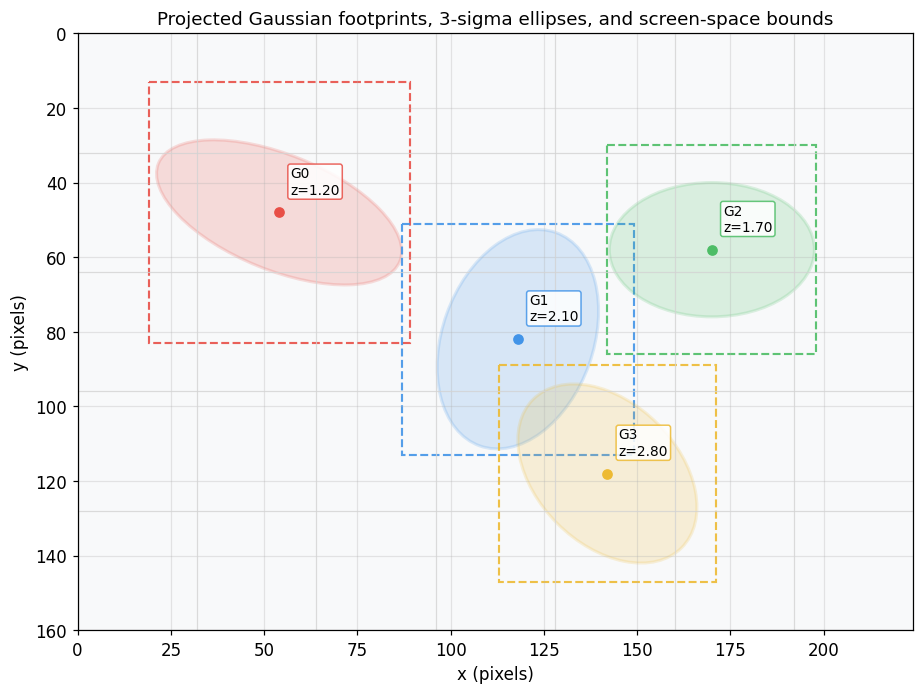

In [3]:
fig, ax = plt.subplots(figsize=(9.4, 6.2), constrained_layout=True)
draw_screen(ax)
for gaussian in base_gaussians:
    add_gaussian_outline(ax, gaussian)
ax.set_title('Projected Gaussian footprints, 3-sigma ellipses, and screen-space bounds')
plt.show()

### What you see

1. **What the output shows:** Each Gaussian appears as a colored ellipse with a dashed square bound around it. The ellipse reflects the covariance, while the square is a conservative screen-space radius used to locate touched tiles.
2. **Why it looks this way:** The rasterizer does not test an infinite Gaussian over the whole screen. It builds a finite bound from the largest covariance eigenvalue and uses that bound as a cheap way to localize work.
3. **What to take away:** The first speed-up happens before blending. Once a Gaussian has a finite 2D footprint, the algorithm can reason about *where not to render it*.

---
## Experiment 2: Tile binning turns one Gaussian into several local jobs

**Question:** How does the renderer organize work after it knows the footprint?

The official `duplicateWithKeys` kernel emits one `(tile, depth)` entry for every tile touched by a Gaussian. This means the rasterizer duplicates *references* to a Gaussian, not the Gaussian parameters themselves. That is the heart of tile-local work scheduling.

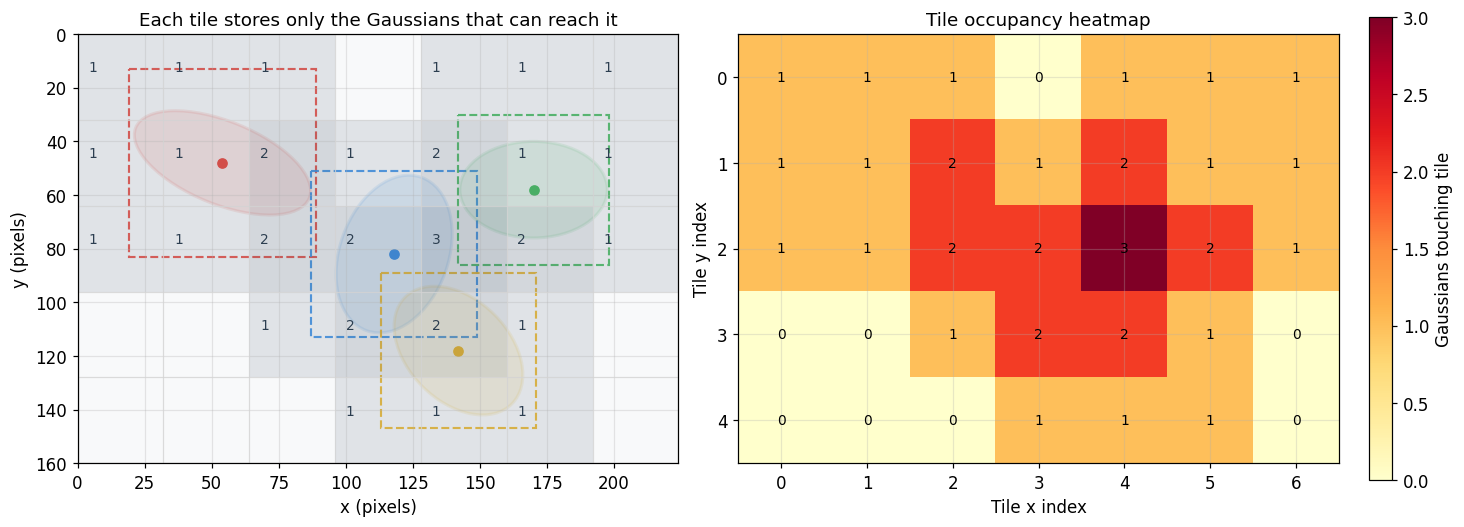

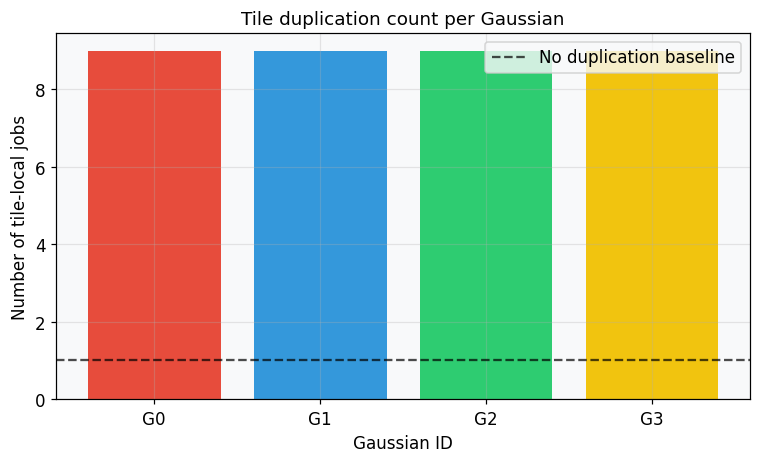

Original Gaussian count: 4
Duplicated tile-local records: 36


In [4]:
duplicates, tile_map = duplicate_by_tile(base_gaussians)

tile_touch_counts = [0] * len(base_gaussians)
for record in duplicates:
    tile_touch_counts[record['gaussian_id']] += 1

heatmap = np.zeros((int(np.ceil(HEIGHT / TILE)), int(np.ceil(WIDTH / TILE))), dtype=int)
for (tx, ty), ids in tile_map.items():
    heatmap[ty, tx] = len(ids)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.1), constrained_layout=True)
draw_screen(axes[0])
for gaussian in base_gaussians:
    add_gaussian_outline(axes[0], gaussian, label=False, face_alpha=0.12)
for (tx, ty), ids in tile_map.items():
    rect = Rectangle((tx * TILE, ty * TILE), TILE, TILE, facecolor='#34495e', alpha=0.07 * len(ids) + 0.05, edgecolor='none')
    axes[0].add_patch(rect)
    axes[0].text(tx * TILE + 4, ty * TILE + 14, str(len(ids)), fontsize=9, color='#2c3e50')
axes[0].set_title('Each tile stores only the Gaussians that can reach it')

im = axes[1].imshow(heatmap, cmap='YlOrRd', origin='upper')
axes[1].set_title('Tile occupancy heatmap')
axes[1].set_xlabel('Tile x index')
axes[1].set_ylabel('Tile y index')
for y in range(heatmap.shape[0]):
    for x in range(heatmap.shape[1]):
        axes[1].text(x, y, str(heatmap[y, x]), ha='center', va='center', color='black', fontsize=9)
fig.colorbar(im, ax=axes[1], shrink=0.85, label='Gaussians touching tile')
plt.show()

fig, ax = plt.subplots(figsize=(6.8, 4.1), constrained_layout=True)
ax.bar([f'G{i}' for i in range(len(base_gaussians))], tile_touch_counts, color=['#e74c3c', '#3498db', '#2ecc71', '#f1c40f'])
ax.axhline(1, color='black', linestyle='--', alpha=0.7, label='No duplication baseline')
ax.set_title('Tile duplication count per Gaussian')
ax.set_xlabel('Gaussian ID')
ax.set_ylabel('Number of tile-local jobs')
ax.legend()
plt.show()

print(f'Original Gaussian count: {len(base_gaussians)}')
print(f'Duplicated tile-local records: {len(duplicates)}')

### What you see

1. **What the output shows:** Some tiles are touched by one Gaussian, while others accumulate several. The bar chart shows that each Gaussian becomes multiple tile-local records, depending on how wide its footprint is.
2. **Why it looks this way:** Tile duplication is the price the renderer pays to gain locality. Once a Gaussian is listed only in the tiles it can affect, pixels outside those tiles never need to see it.
3. **What to take away:** Rasterization becomes fast by trading one global scene list for many small local queues. The duplication cost is usually worth it because it shrinks the candidate set for almost every pixel.

---
## Experiment 3: Sorting by `(tile, depth)` creates visibility-aware local queues

**Question:** Why is sorting part of the rasterizer instead of just an implementation detail?

A touched tile is not enough. The Gaussians inside that tile must also be processed from near to far, otherwise front-to-back compositing will be wrong. This experiment makes the queue structure explicit for one busy tile.

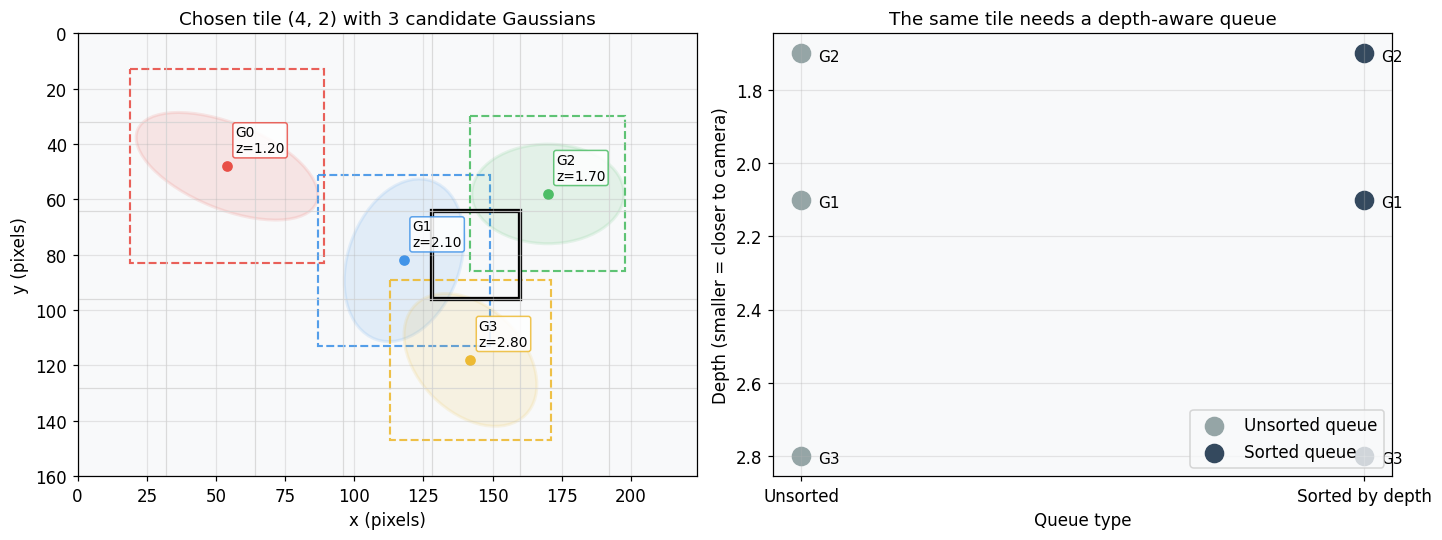

Sample tile: (4, 2)
Unsorted queue : [1, 2, 3]
Sorted queue   : [2, 1, 3]


In [5]:
sample_tile = max(tile_map.keys(), key=lambda key: len(tile_map[key]))
queue_unsorted = tile_map[sample_tile]
queue_sorted = sorted(queue_unsorted, key=lambda gid: gaussians_by_id[gid]['depth'])

tx, ty = sample_tile
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8), constrained_layout=True)
draw_screen(axes[0])
for gaussian in base_gaussians:
    add_gaussian_outline(axes[0], gaussian, label=True, face_alpha=0.12)
focus = Rectangle((tx * TILE, ty * TILE), TILE, TILE, fill=False, linewidth=2.8, edgecolor='black')
axes[0].add_patch(focus)
axes[0].set_title(f'Chosen tile ({tx}, {ty}) with {len(queue_unsorted)} candidate Gaussians')

positions = np.arange(len(queue_sorted))
axes[1].scatter(np.zeros_like(positions), [gaussians_by_id[gid]['depth'] for gid in queue_unsorted], s=140, color='#95a5a6', label='Unsorted queue')
axes[1].scatter(np.ones_like(positions), [gaussians_by_id[gid]['depth'] for gid in queue_sorted], s=140, color='#34495e', label='Sorted queue')
for side_x, queue, title in [(0, queue_unsorted, 'Before sorting'), (1, queue_sorted, 'After sorting')]:
    for gid in queue:
        depth = gaussians_by_id[gid]['depth']
        axes[1].text(side_x + 0.03, depth + 0.02, f'G{gid}', fontsize=10)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Unsorted', 'Sorted by depth'])
axes[1].set_title('The same tile needs a depth-aware queue')
axes[1].set_xlabel('Queue type')
axes[1].set_ylabel('Depth (smaller = closer to camera)')
axes[1].invert_yaxis()
axes[1].legend(loc='lower right')
plt.show()

print(f'Sample tile: {sample_tile}')
print('Unsorted queue :', queue_unsorted)
print('Sorted queue   :', queue_sorted)

### What you see

1. **What the output shows:** The highlighted tile receives several overlapping Gaussians. The right-hand panel shows the same tile-local queue before and after sorting by depth.
2. **Why it looks this way:** Front-to-back compositing assumes nearer Gaussians consume transmittance first. If a farther Gaussian is blended too early, it incorrectly steals color budget from the closer one.
3. **What to take away:** Sorting is not cosmetic. It is the mechanism that turns tile-local queues into a visibility-aware rendering order.

---
## Experiment 4: Front-to-back compositing is order-sensitive

**Question:** What actually breaks if we blend in the wrong order?

We now render the same set of Gaussians twice: once with the correct depth order inside each tile, and once with the order intentionally reversed. We will also inspect the transmittance curve at a pixel near the center of overlap.

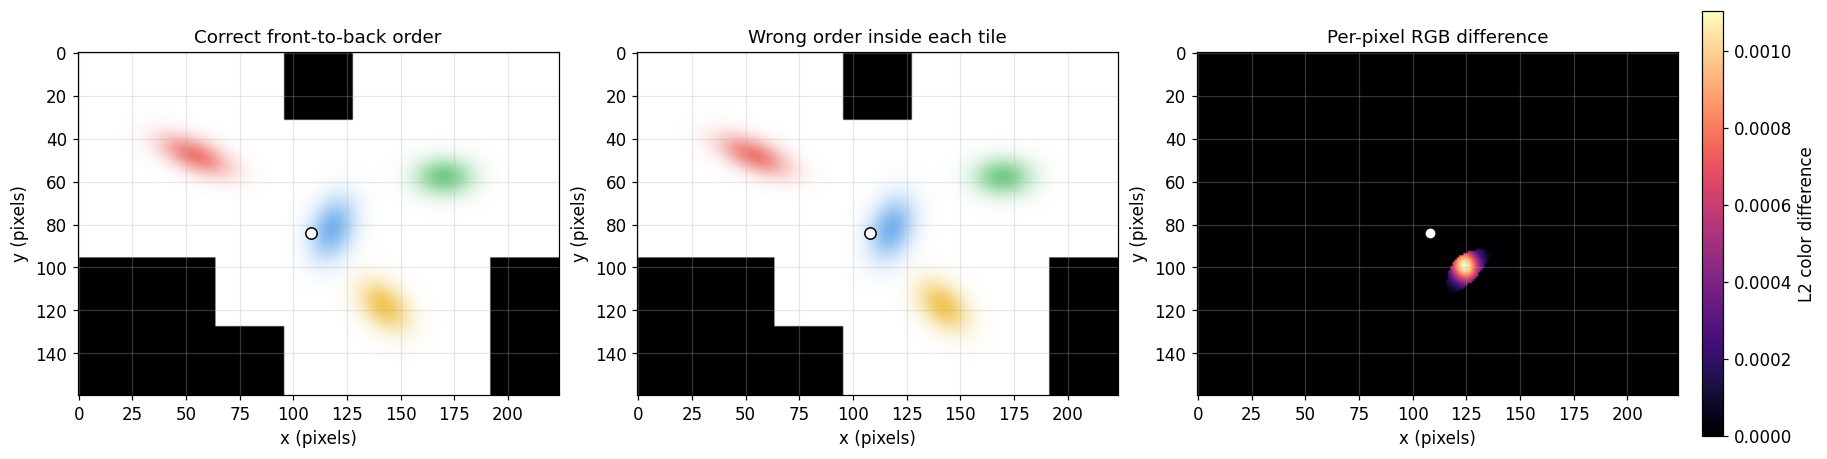

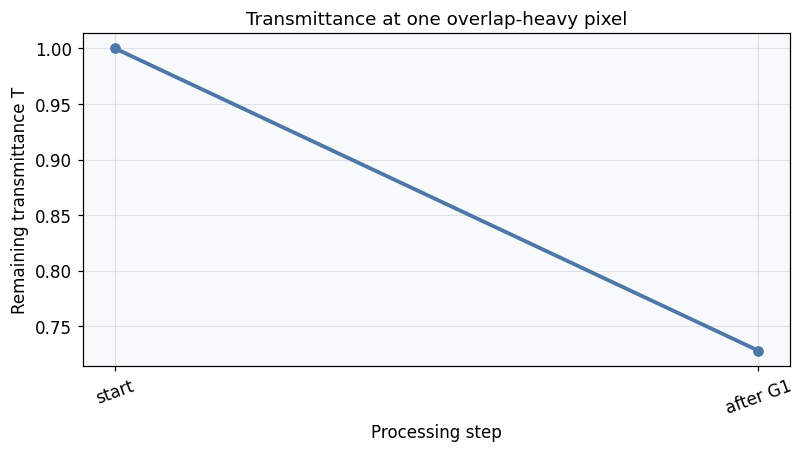

In [6]:
sorted_result = render_scene(base_gaussians, sort_by_depth=True, early_stop_threshold=None)
reversed_gaussians = sorted(base_gaussians, key=lambda g: g['depth'], reverse=True)
reversed_lookup = {g['id']: g for g in reversed_gaussians}
gaussians_by_id = reversed_lookup
wrong_result = render_scene(reversed_gaussians, sort_by_depth=False, early_stop_threshold=None)
gaussians_by_id = {g['id']: g for g in base_gaussians}

focus_pixel = (108, 84)
queue = sorted_result['queues'][sample_tile]
T = 1.0
trajectory = [T]
labels = ['start']
for gid in queue:
    gaussian = gaussians_by_id[gid]
    alpha = gaussian_alpha_map(gaussian, np.array([[focus_pixel[0]]]), np.array([[focus_pixel[1]]]))[0, 0]
    if alpha > 0:
        T = T * (1.0 - alpha)
        trajectory.append(T)
        labels.append(f'after G{gid}')

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8), constrained_layout=True)
axes[0].imshow(sorted_result['image'], origin='upper')
axes[0].scatter([focus_pixel[0]], [focus_pixel[1]], color='white', edgecolor='black', s=55)
axes[0].set_title('Correct front-to-back order')
axes[0].set_xlabel('x (pixels)')
axes[0].set_ylabel('y (pixels)')

axes[1].imshow(wrong_result['image'], origin='upper')
axes[1].scatter([focus_pixel[0]], [focus_pixel[1]], color='white', edgecolor='black', s=55)
axes[1].set_title('Wrong order inside each tile')
axes[1].set_xlabel('x (pixels)')
axes[1].set_ylabel('y (pixels)')

error_map = np.linalg.norm(sorted_result['image'] - wrong_result['image'], axis=-1)
im = axes[2].imshow(error_map, origin='upper', cmap='magma')
axes[2].scatter([focus_pixel[0]], [focus_pixel[1]], color='white', edgecolor='black', s=55)
axes[2].set_title('Per-pixel RGB difference')
axes[2].set_xlabel('x (pixels)')
axes[2].set_ylabel('y (pixels)')
fig.colorbar(im, ax=axes[2], shrink=0.82, label='L2 color difference')
plt.show()

fig, ax = plt.subplots(figsize=(7.2, 4.0), constrained_layout=True)
ax.plot(np.arange(len(trajectory)), trajectory, marker='o', linewidth=2.5, color='#4C78A8')
ax.set_title('Transmittance at one overlap-heavy pixel')
ax.set_xlabel('Processing step')
ax.set_ylabel('Remaining transmittance T')
ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=20)
plt.show()

### What you see

1. **What the output shows:** The correctly sorted image and the intentionally misordered image differ most in overlap-heavy regions. The transmittance curve at the marked pixel falls as nearer Gaussians consume visibility.
2. **Why it looks this way:** Front-to-back blending is multiplicative in transmittance. Once a Gaussian reduces `T`, every later Gaussian is discounted. The order therefore changes both visibility and color.
3. **What to take away:** Gaussian rasterization is not just “draw some ellipses.” It is “draw tile-local ellipses in a depth-aware order, while carrying forward residual visibility.”

---
## Experiment 5: Tile culling and early termination save real work

**Question:** Where does the practical speed-up over naive rendering come from?

We enlarge the scene with many additional far-depth Gaussians and compare three counting models:

1. **Naive all-to-all:** every pixel tests every Gaussian.
2. **Tile-aware only:** each pixel tests only Gaussians in its tile queue.
3. **Tile-aware + early stop:** each pixel can stop once transmittance is already tiny.

This is still a toy benchmark, but it reveals the same structural savings as the official rasterizer.

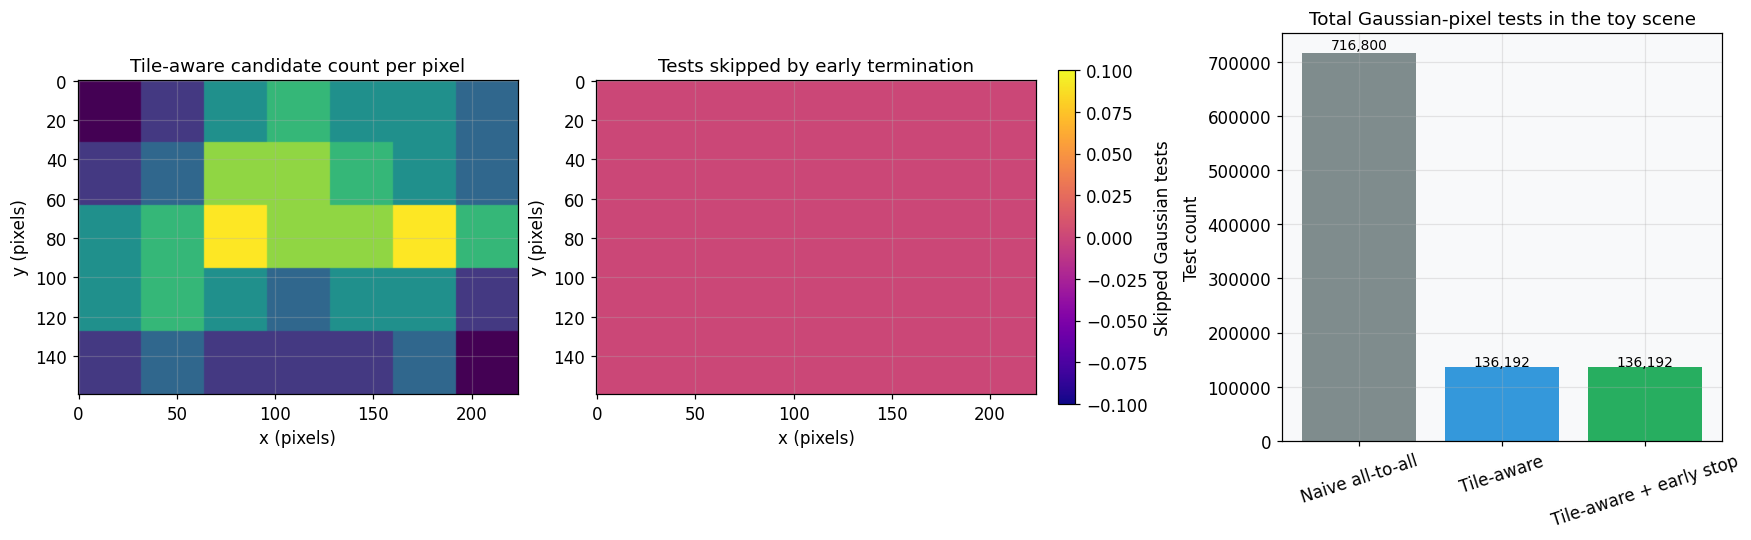

Total Gaussians in dense scene: 20
Naive all-to-all tests      : 716,800
Tile-aware tests            : 136,192
Tile-aware + early-stop     : 136,192


In [7]:
dense_gaussians = list(base_gaussians)
for extra_id in range(4, 20):
    mean = (
        np.random.uniform(20, WIDTH - 20),
        np.random.uniform(20, HEIGHT - 20),
    )
    scale_x = np.random.uniform(24, 88)
    scale_y = np.random.uniform(16, 72)
    cross = np.random.uniform(-18, 18)
    cov = np.array([[scale_x, cross], [cross, scale_y]], dtype=float)
    cov[1, 1] = max(cov[1, 1], 14)
    cov[0, 0] = max(cov[0, 0], 14)
    dense_gaussians.append(
        make_gaussian(
            extra_id,
            mean=mean,
            cov=cov,
            depth=np.random.uniform(1.0, 5.0),
            opacity=np.random.uniform(0.35, 0.82),
            color=np.clip(np.random.uniform(0.1, 0.95, size=3), 0.0, 1.0),
        )
    )

gaussians_by_id = {g['id']: g for g in dense_gaussians}
res_tile_only = render_scene(dense_gaussians, sort_by_depth=True, early_stop_threshold=None)
res_tile_early = render_scene(dense_gaussians, sort_by_depth=True, early_stop_threshold=1e-3)
gaussians_by_id = {g['id']: g for g in base_gaussians}

naive_total_tests = WIDTH * HEIGHT * len(dense_gaussians)
tile_only_total_tests = int(res_tile_only['tested'].sum())
early_total_tests = int(res_tile_early['tested'].sum())

fig, axes = plt.subplots(1, 3, figsize=(15.8, 4.8), constrained_layout=True)
axes[0].imshow(res_tile_only['tested'], origin='upper', cmap='viridis')
axes[0].set_title('Tile-aware candidate count per pixel')
axes[0].set_xlabel('x (pixels)')
axes[0].set_ylabel('y (pixels)')

saving_map = res_tile_only['tested'] - res_tile_early['tested']
im = axes[1].imshow(saving_map, origin='upper', cmap='plasma')
axes[1].set_title('Tests skipped by early termination')
axes[1].set_xlabel('x (pixels)')
axes[1].set_ylabel('y (pixels)')
fig.colorbar(im, ax=axes[1], shrink=0.82, label='Skipped Gaussian tests')

bars = [naive_total_tests, tile_only_total_tests, early_total_tests]
labels = ['Naive all-to-all', 'Tile-aware', 'Tile-aware + early stop']
colors = ['#7f8c8d', '#3498db', '#27ae60']
axes[2].bar(labels, bars, color=colors)
axes[2].set_title('Total Gaussian-pixel tests in the toy scene')
axes[2].set_ylabel('Test count')
axes[2].tick_params(axis='x', rotation=18)
for index, value in enumerate(bars):
    axes[2].text(index, value * 1.01, f'{value:,}', ha='center', fontsize=9)
plt.show()

print(f'Total Gaussians in dense scene: {len(dense_gaussians)}')
print(f'Naive all-to-all tests      : {naive_total_tests:,}')
print(f'Tile-aware tests            : {tile_only_total_tests:,}')
print(f'Tile-aware + early-stop     : {early_total_tests:,}')

### What you see

1. **What the output shows:** The tile-aware renderer already reduces the candidate count unevenly across the screen, because empty or lightly populated regions test far fewer Gaussians than overlap-heavy zones. Early termination saves even more tests in already-opaque regions.
2. **Why it looks this way:** Two separate mechanisms help. Tile binning shrinks the candidate set before blending begins, and front-to-back compositing lets a pixel stop once almost no transmittance remains.
3. **What to take away:** The speed-up in Gaussian rasterization is not one magical trick. It is the combination of bounded footprints, tile-local queues, depth-aware order, and early visibility saturation.

---
## Summary / Key Takeaways

- **A Gaussian rasterizer works with projected ellipses, not with raw 3D points.** Covariance becomes a finite 2D footprint with a practical screen-space bound.
- **Tile duplication is deliberate.** It trades a few extra records for much smaller local candidate lists.
- **Sorting by depth is essential.** Front-to-back transmittance only makes sense if the queue respects visibility order.
- **Alpha compositing is the decoder logic.** Once geometry and appearance are known, rendering becomes repeated local updates of color and residual transmittance.
- **The speed-up is structural.** Tile culling and early termination attack unnecessary work before and during blending, which is why Gaussian rasterization scales so much better than naive all-to-all rendering.